# **Exploratory Data Analysis: Before Pupil Detection**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 17.03.2026

## **Table of Contents**

1. [Imports](#imports)
2. [Dataset Indexing](#dataset-indexing)
3. [General Information](#general-information)
    - [Dataset Overview](#dataset-overview)
    - [Unique values](#unique-values)
    - [Missing values](#missing-values)
    - [Target balance](#target-balance)
    - [Image Resolution](#image-resolution)
    - [Image Color Mode](#image-color-mode)
4. [Distributions](#distributions)
    - [Image Distribution per Subject](#image-distribution-per-subject)
    - [Image Distribution per Target](#image-distribution-per-target)
    - [Subject-Target Distribution](#subject-target-distribution)
5. [Sample Images](#sample-images)

<br/>

## **Imports**

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

<br/>

## **Dataset Indexing**

In [2]:
# Project paths
ROOT_DIR = Path("../..").resolve()
DATA_DIR = ROOT_DIR / "data"

# Screen resolution
SCREEN_WIDTH = 1440
SCREEN_HEIGHT = 900

# Create normalized grid positions (5x5)
xs = np.linspace(0.15, 0.85, 5)
ys = np.linspace(0.15, 0.85, 5)

# Convert target id (0-24) to normalized (x, y)
def get_norm_coord(target_id):
    row = target_id // 5
    col = target_id % 5
    return xs[col], ys[row]

# Normalize paths to consistent format (remove ../ etc.)
def normalize_path(path_str):
    path_str = str(path_str).strip().replace("\\", "/")
    path_str = path_str.replace("../", "")
    return path_str

# Find all image paths
paths = list(DATA_DIR.glob("*/*/*.png"))

rows = []
for p in paths:
        
    subject = p.parts[-3]                 # e.g. 001
    filename = p.stem                     # e.g. 00_1771...
    target = int(filename.split("_")[0])  # target id (0–24)

    # Compute coordinates
    x_norm, y_norm = get_norm_coord(target)
    x_pixel = x_norm * SCREEN_WIDTH
    y_pixel = y_norm * SCREEN_HEIGHT

    rows.append({
        "subject": subject,
        "target": target,
        "x_norm": x_norm,
        "y_norm": y_norm,
        "x_pixel": x_pixel,
        "y_pixel": y_pixel,
        # Store path relative to project root (data/...)
        "path": str(p.relative_to(ROOT_DIR)).replace("\\", "/")
        })

# Create DataFrame
df = pd.DataFrame(rows)

# Normalize paths for matching
df["path"] = df["path"].apply(normalize_path)

# Sort for consistency
df = df.sort_values(["subject", "target", "path"]).reset_index(drop=True)

print("Rows before pupil detection:", len(df))
df.head()

Rows before pupil detection: 111103


,subject,target,x_norm,y_norm,x_pixel,y_pixel,path
0,001,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694463536000.png
1,001,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694495373000.png
2,001,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694526693000.png
3,001,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694557769000.png
4,001,0,0.15,0.15,216.0,135.0,data/001/frames/00_1771844694589347000.png


In [3]:
df.sample(30)

,subject,target,x_norm,y_norm,x_pixel,y_pixel,path
49118,021,13,0.675,0.500,972.0,450.0,data/021/frames/13_1771952031812124000.png
52903,023,2,0.500,0.150,720.0,135.0,data/023/frames/02_1771952724334987000.png
92729,039,11,0.325,0.500,468.0,450.0,data/039/frames/11_1772198203394496000.png
65155,028,2,0.500,0.150,720.0,135.0,data/028/frames/02_1772036946743046000.png
91907,039,2,0.500,0.150,720.0,135.0,data/039/frames/02_1772198206871332000.png
66822,028,19,0.850,0.675,1224.0,607.5,data/028/frames/19_1772036942293207000.png
46889,020,15,0.150,0.675,216.0,607.5,data/020/frames/15_1771950524928372000.png
29566,013,12,0.500,0.500,720.0,450.0,data/013/frames/12_1771930110393002000.png
105513,044,17,0.500,0.675,720.0,607.5,data/044/frames/17_1772206310601178000.png
97906,041,14,0.850,0.500,1224.0,450.0,data/041/frames/14_1772201877810807000.png


<br/>

## **General Information**

### Dataset Overview

In [4]:
print("Total images:", len(df))
print("Unique subjects:", df.subject.nunique())
print("Unique targets:", df.target.nunique())

Total images: 111103
Unique subjects: 46
Unique targets: 25


### Unique values

In [5]:
print("Unique subjects:", df["subject"].nunique())
print("Unique targets:", df["target"].nunique())
print("\nUnique x_norm:", sorted(df["x_norm"].unique()))
print("Unique y_norm:", sorted(df["y_norm"].unique()))

Unique subjects: 46
Unique targets: 25

Unique x_norm: [np.float64(0.15), np.float64(0.32499999999999996), np.float64(0.5), np.float64(0.6749999999999999), np.float64(0.85)]
Unique y_norm: [np.float64(0.15), np.float64(0.32499999999999996), np.float64(0.5), np.float64(0.6749999999999999), np.float64(0.85)]


### Missing values

In [6]:
print(df.isnull().sum())

subject    0
target     0
x_norm     0
y_norm     0
x_pixel    0
y_pixel    0
path       0
dtype: int64


### Target balance

In [7]:
target_counts = df["target"].value_counts().sort_index()
#print(target_counts)

target_counts.describe()

count      25.000000
mean     4444.120000
std         3.073001
min      4435.000000
25%      4442.000000
50%      4444.000000
75%      4446.000000
max      4449.000000
Name: count, dtype: float64

### Image Resolution

In [8]:
sizes = []

sample_paths = df.path.sample(2000, random_state=42)

for p in tqdm(sample_paths):
    with Image.open(ROOT_DIR / p) as img:
        sizes.append(img.size)

pd.Series(sizes).value_counts()

100%|██████████| 2000/2000 [00:24<00:00, 82.67it/s]


(2048, 1536)    2000
Name: count, dtype: int64

### Image Color Mode

In [9]:
modes = []

for p in tqdm(sample_paths):
    with Image.open(ROOT_DIR / p) as img:
        modes.append(img.mode)

pd.Series(modes).value_counts()

100%|██████████| 2000/2000 [00:23<00:00, 84.50it/s]


RGB    2000
Name: count, dtype: int64

<br/>

## **Distributions**

### Image Distribution per Subject

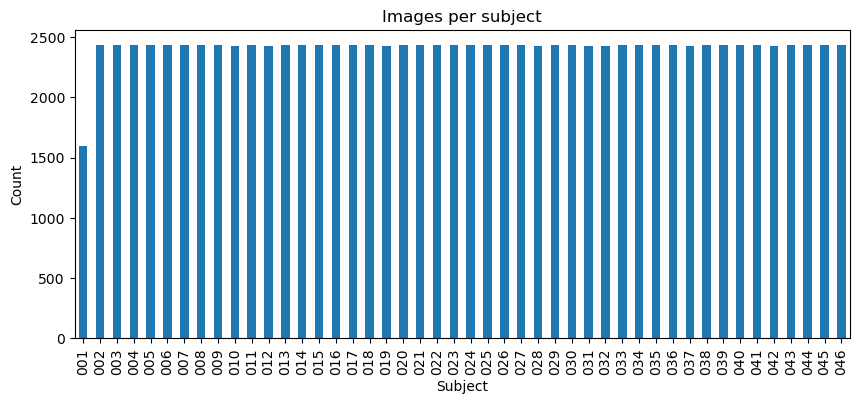

In [10]:
subject_counts = df.subject.value_counts().sort_index()
#print(subject_counts)

plt.figure(figsize=(10,4))
subject_counts.plot(kind="bar")
plt.title("Images per subject")
plt.xlabel("Subject")
plt.ylabel("Count")
plt.show()

### Image Distribution per Target

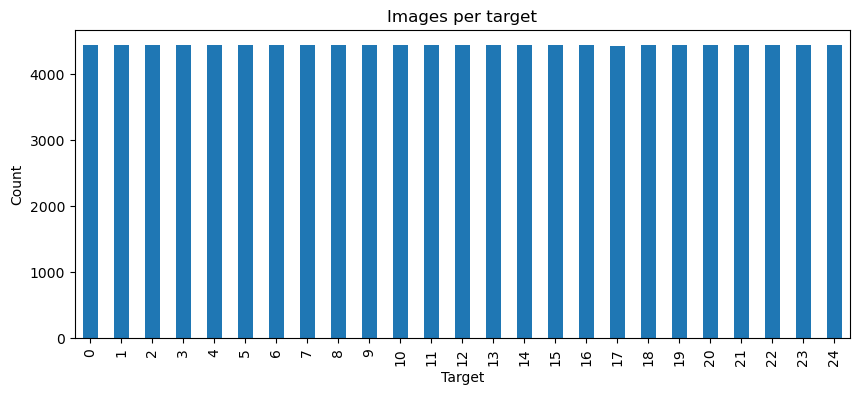

In [11]:
target_counts = df.target.value_counts().sort_index()
#print(target_counts)

plt.figure(figsize=(10,4))
target_counts.plot(kind="bar")
plt.title("Images per target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

### Subject-Target Distribution

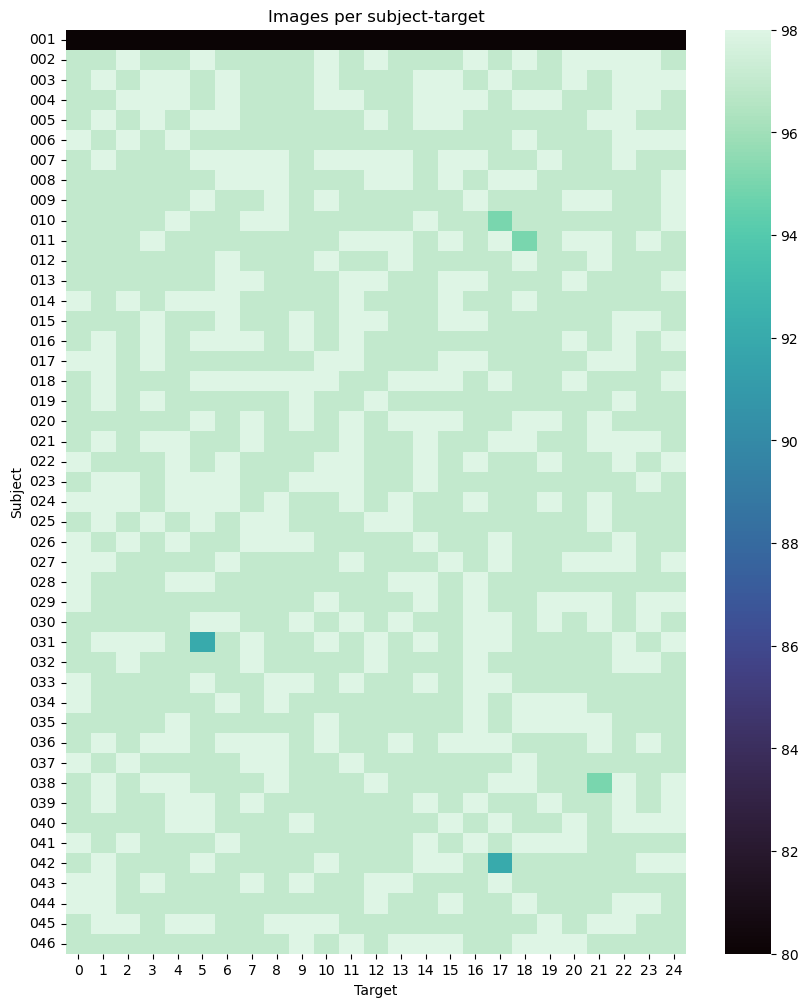

In [12]:
pivot = pd.crosstab(df.subject, df.target)
#print(pivot)

plt.figure(figsize=(10,12))
sns.heatmap(pivot, cmap="mako", vmin=80, vmax=98)
plt.title("Images per subject-target")
plt.xlabel("Target")
plt.ylabel("Subject")
plt.show()

<br/>

## **Sample images**

In [ ]:
sample = df.sample(25, random_state=42)

plt.figure(figsize=(10, 10))

for i, row in enumerate(sample.itertuples()):
    with Image.open(ROOT_DIR / row.path) as img:
        plt.subplot(5, 5, i + 1)
        plt.imshow(img)
        plt.title(f"S:{row.subject} T:{row.target}")
        plt.axis("off")

plt.tight_layout()
plt.show()